In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

plt.style.use('dark_background')
plt.rcParams.update({'figure.facecolor': '#111', 'axes.facecolor': '#1a1a1a',
                     'axes.edgecolor': '#333', 'grid.color': '#2a2a2a',
                     'font.family': 'sans-serif', 'font.size': 11})

## Cargar último run

In [2]:
RUNS_DIR = Path('runs')
PROJECTS_FILE = Path('projects.json')

aliases = json.loads(PROJECTS_FILE.read_text()) if PROJECTS_FILE.exists() else {}

latest = sorted(RUNS_DIR.glob('*.json'))[-1]
run = json.loads(latest.read_text())
print(f'Run: {latest.name}')
print(f'Timestamp: {run["timestamp_display"]}')

STAGE_ORDER = ['PENDING_ARRIVAL','RECEIVED','SAMPLE_QC',
               'LIB_PREP_OR_SEQUENCING','DATA_QC','FINAL_REPORT','DATA_RELEASE']
STAGE_LABELS = {
    'PENDING_ARRIVAL': 'Pending Arrival',
    'RECEIVED': 'Received',
    'SAMPLE_QC': 'Sample QC',
    'LIB_PREP_OR_SEQUENCING': 'Lib Prep / Seq',
    'DATA_QC': 'Data QC',
    'FINAL_REPORT': 'Final Report',
    'DATA_RELEASE': 'Data Release',
}
TRANS_KEYS = [f'{STAGE_ORDER[i]}\u2192{STAGE_ORDER[i+1]}' for i in range(len(STAGE_ORDER)-1)]
TRANS_LABELS = [
    'Envío → Recepción', 'Recepción → QC', 'QC → Secuenciación',
    'Secuenciación → Data QC', 'Data QC → Reporte', 'Reporte → Data Release',
]

Run: 2026-06-09T17-07-35.380.json
Timestamp: 2026-06-09 17:07 UTC


In [3]:
rows = []
for p in run['projects']:
    alias = aliases.get(p['sub_project_no'], p['sub_project_no'])
    for s in p['samples']:
        row = {
            'project': p['sub_project_no'],
            'alias': alias,
            'sample': s['sample_name'],
            'novo_id': s['novo_id'],
            'status': s['current_status'],
            'status_label': s['current_status_meaning'],
            'is_complete': s['is_complete'],
            'is_delayed': s['is_delayed'],
            'needs_data_release': s['needs_data_release'],
            'tat': s['tat_received_to_release'],
            'tat_from_pending': s['tat_pending_to_release'],
        }
        for stage in STAGE_ORDER:
            dt = s['timeline'].get(stage)
            row[f'date_{stage}'] = pd.to_datetime(dt) if dt else pd.NaT
        for tk in TRANS_KEYS:
            row[f'dur_{tk}'] = s.get('stage_durations', {}).get(tk)
        rows.append(row)

df = pd.DataFrame(rows)
df['tat'] = pd.to_numeric(df['tat'], errors='coerce')
df['tat_from_pending'] = pd.to_numeric(df['tat_from_pending'], errors='coerce')

for tk in TRANS_KEYS:
    df[f'dur_{tk}'] = pd.to_numeric(df[f'dur_{tk}'], errors='coerce')

print(f'{len(df)} muestras totales')
df.head(3)

73 muestras totales


,project,alias,sample,novo_id,status,status_label,is_complete,is_delayed,needs_data_release,tat,...,date_LIB_PREP_OR_SEQUENCING,date_DATA_QC,date_FINAL_REPORT,date_DATA_RELEASE,dur_PENDING_ARRIVAL→RECEIVED,dur_RECEIVED→SAMPLE_QC,dur_SAMPLE_QC→LIB_PREP_OR_SEQUENCING,dur_LIB_PREP_OR_SEQUENCING→DATA_QC,dur_DATA_QC→FINAL_REPORT,dur_FINAL_REPORT→DATA_RELEASE
0,X202SC25109710-Z01,BRCA,HG25BRC0021,FKDN250784639-1A,DESTROYED,Sample Disposed,True,False,False,20.0,...,2025-11-26 17:20:26,NaT,2025-12-05 18:10:04,2025-12-09 19:49:12,13.0,0.0,7.0,NaN,NaN,4.0
1,X202SC25109710-Z01,BRCA,HG25BRC0022,FKDN250924792-1A,SAMPLE_QC,Sample QC,False,True,True,NaN,...,NaT,NaT,NaT,NaT,19.0,0.0,NaN,NaN,NaN,NaN
2,X202SC25109710-Z01,BRCA,HG25BRC0023,FKDN250924793-1A,DATA_RELEASE,Data Release,True,False,False,12.0,...,2025-12-13 16:10:15,NaT,2025-12-19 18:39:39,2025-12-22 16:43:26,19.0,0.0,3.0,NaN,NaN,2.0


## Resumen general

In [4]:
summary = df.groupby('alias').agg(
    muestras=('sample', 'count'),
    completadas=('is_complete', 'sum'),
    en_proceso=('needs_data_release', 'sum'),
    retrasadas=('is_delayed', 'sum'),
    tat_promedio=('tat', 'mean'),
    tat_mediana=('tat', 'median'),
    tat_min=('tat', 'min'),
    tat_max=('tat', 'max'),
).round(1)
summary['completadas'] = summary['completadas'].astype(int)
summary['en_proceso'] = summary['en_proceso'].astype(int)
summary['retrasadas'] = summary['retrasadas'].astype(int)
summary

,muestras,completadas,en_proceso,retrasadas,tat_promedio,tat_mediana,tat_min,tat_max
alias,,,,,,,,
BRCA,16,7,9,2,17.0,14.0,12.0,27.0
Exoma,57,49,8,3,19.8,20.0,13.0,32.0


In [5]:
df_complete = df[df['tat'].notna()]
print('=== TAT global (días recibido → data release) ===')
print(df_complete['tat'].describe().round(1).to_string())

=== TAT global (días recibido → data release) ===
count    56.0
mean     19.4
std       5.3
min      12.0
25%      14.0
50%      20.0
75%      23.0
max      32.0


## Estado actual de las muestras

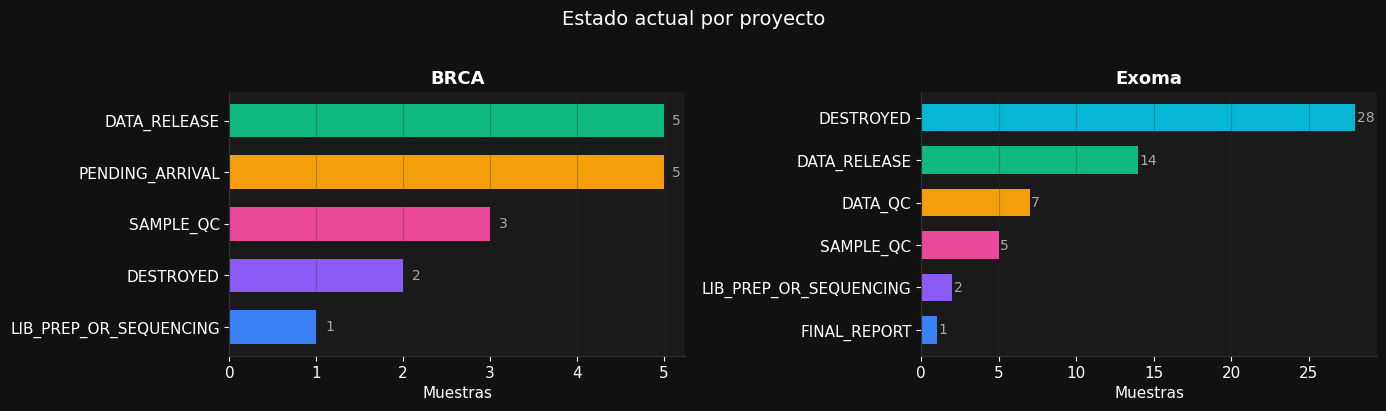

In [19]:
fd = df  #[df["status"]!="DESTROYED"]
status_counts = (fd.groupby(['alias', 'status'])
                   .size()
                   .reset_index(name='n')
                   .sort_values(['alias', 'n'], ascending=[True, False]))

fig, axes = plt.subplots(1, len(fd['alias'].unique()), figsize=(14, 4), sharey=False)
COLORS = ['#3b82f6','#8b5cf6','#ec4899','#f59e0b','#10b981','#06b6d4','#6b7280','#ef4444']

for ax, (alias, grp) in zip(axes, status_counts.groupby('alias')):
    grp = grp.sort_values('n')
    colors = [COLORS[i % len(COLORS)] for i in range(len(grp))]
    ax.barh(grp['status'], grp['n'], color=colors, height=0.65)
    for _, row in grp.iterrows():
        ax.text(row['n'] + 0.1, row['status'], str(row['n']),
                va='center', fontsize=10, color='#aaa')
    ax.set_title(alias, fontsize=13, fontweight='bold')
    ax.set_xlabel('Muestras')
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Estado actual por proyecto', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Distribución TAT (boxplot comparativo)

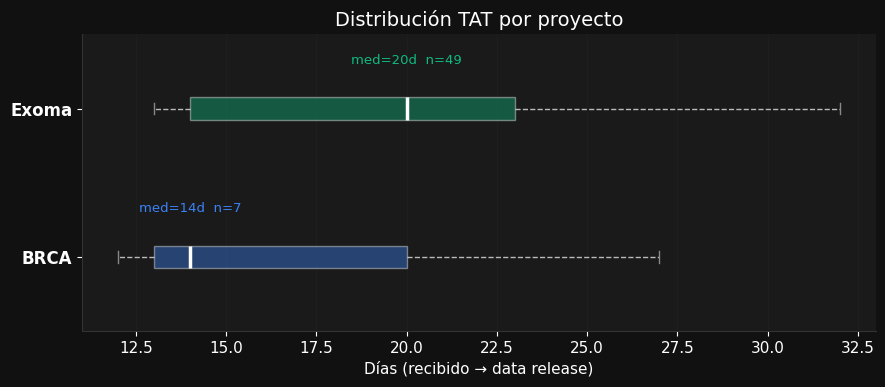

In [18]:
groups = [df_complete[(df_complete['alias'] == a)]['tat'].values
          for a in df_complete['alias'].unique()]
labels = list(df_complete['alias'].unique())
colors = ['#3b82f6', '#10b981']

fig, ax = plt.subplots(figsize=(9, 4))
bp = ax.boxplot(groups, vert=False, patch_artist=True,
                medianprops=dict(color='white', linewidth=2.5),
                whiskerprops=dict(linestyle='--', alpha=0.7),
                flierprops=dict(marker='o', markersize=5, alpha=0.6))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.4)
for cap in bp['caps']:
    cap.set_color('#888')
for flier, color in zip(bp['fliers'], colors):
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)

ax.set_yticks(range(1, len(labels) + 1))
ax.set_yticklabels(labels, fontsize=12, fontweight='bold')
ax.set_xlabel('Días (recibido → data release)')
ax.set_title('Distribución TAT por proyecto', fontsize=14)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotate medians
for i, (grp, color) in enumerate(zip(groups, colors), 1):
    med = pd.Series(grp).median()
    n = len(grp)
    ax.text(med, i + 0.28, f'med={med:.0f}d  n={n}',
            ha='center', va='bottom', fontsize=9.5, color=color)

plt.tight_layout()
plt.show()

## Cuello de botella — días promedio por transición

In [16]:
bk_rows = []
for tk, lbl in zip(TRANS_KEYS, TRANS_LABELS):
    col = f'dur_{tk}'
    for alias, grp in df.groupby('alias'):
        vals = grp[col].dropna()
        if len(vals) > 0:
            bk_rows.append({'alias': alias, 'transition': lbl,
                            'avg': vals.mean(), 'max': vals.max(), 'n': len(vals)})

bk = pd.DataFrame(bk_rows).round(1)
bk_pivot = bk.pivot(index='transition', columns='alias', values='avg')
# preserve pipeline order
order = [l for l in TRANS_LABELS if l in bk_pivot.index]
bk_pivot = bk_pivot.loc[order]
bk_pivot

alias,BRCA,Exoma
transition,,
Envío → Recepción,18.8,4.5
Recepción → QC,0.1,0.3
QC → Secuenciación,5.4,5.3
Secuenciación → Data QC,NaN,15.1
Data QC → Reporte,NaN,4.9
Reporte → Data Release,0.9,1.1


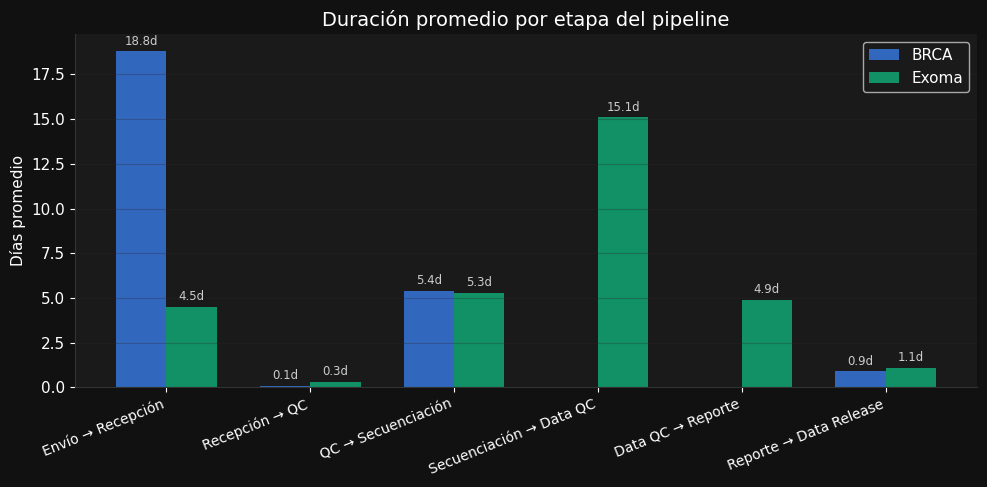

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
n_groups = len(bk_pivot)
x = range(n_groups)
width = 0.35
cols_bp = bk_pivot.columns.tolist()

for i, (alias, color) in enumerate(zip(cols_bp, colors)):
    vals = bk_pivot[alias].fillna(0)
    bars = ax.bar([xi + i * width for xi in x], vals, width,
                  label=alias, color=color, alpha=0.75)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                    f'{v:.1f}d', ha='center', va='bottom', fontsize=8.5, color='#ccc')

ax.set_xticks([xi + width/2 for xi in x])
ax.set_xticklabels(order, rotation=22, ha='right', fontsize=10)
ax.set_ylabel('Días promedio')
ax.set_title('Duración promedio por etapa del pipeline', fontsize=14)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## TAT en el tiempo (muestras completadas)

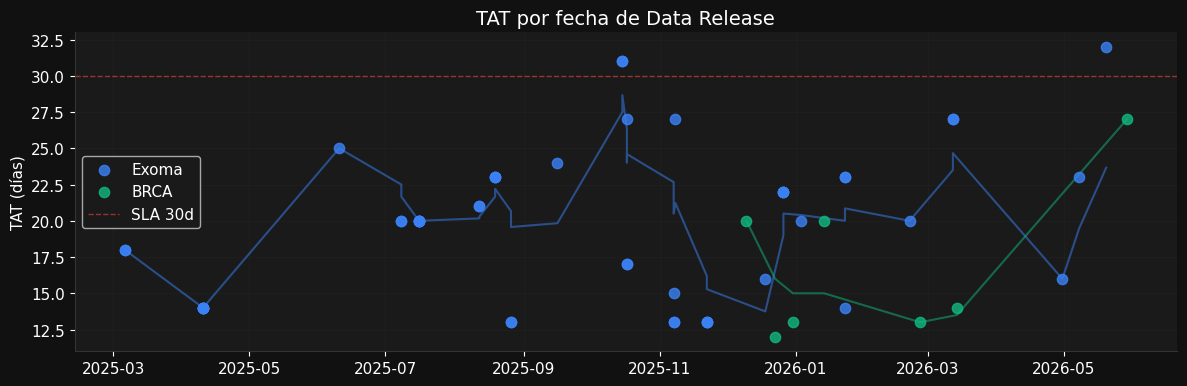

In [10]:
df_t = df_complete.copy()
df_t = df_t[df_t['date_DATA_RELEASE'].notna()].copy()
df_t = df_t.sort_values('date_DATA_RELEASE')

fig, ax = plt.subplots(figsize=(12, 4))

for alias, color in zip(df_t['alias'].unique(), colors):
    grp = df_t[df_t['alias'] == alias]
    ax.scatter(grp['date_DATA_RELEASE'], grp['tat'],
               color=color, label=alias, s=55, alpha=0.8, zorder=3)
    if len(grp) > 1:
        # Rolling average
        rolled = grp.set_index('date_DATA_RELEASE')['tat'].rolling('30D').mean()
        ax.plot(rolled.index, rolled.values, color=color, alpha=0.5, linewidth=1.5)

ax.axhline(30, color='#ef4444', linestyle='--', linewidth=1, alpha=0.6, label='SLA 30d')
ax.set_ylabel('TAT (días)')
ax.set_title('TAT por fecha de Data Release', fontsize=14)
ax.legend()
ax.grid(alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Muestras sin Data Release

In [11]:
pending = df[df['needs_data_release']].copy()
pending['received'] = pending['date_RECEIVED'].dt.strftime('%Y-%m-%d')
pending['days_waiting'] = (pd.Timestamp.now() - pending['date_RECEIVED']).dt.days

display_cols = ['alias', 'sample', 'status_label', 'received', 'days_waiting']
pending[display_cols].sort_values(['alias', 'days_waiting'], ascending=[True, False]).reset_index(drop=True)

,alias,sample,status_label,received,days_waiting
0,BRCA,HG25BRC0022,Sample QC,2025-12-09,181.0
1,BRCA,HG25BRC0024,Sample QC,2025-12-24,167.0
2,BRCA,HG26BRC0007,Sample QC,2026-06-03,5.0
3,BRCA,HG26BRC0008,Library Prep/Sequencing,2026-06-03,5.0
4,BRCA,HG26BRC0002,Pending Arrival,NaN,NaN
5,BRCA,HG26BRC0005,Pending Arrival,NaN,NaN
6,BRCA,HG26BRC0006,Pending Arrival,NaN,NaN
7,BRCA,HG26BRC0009,Pending Arrival,NaN,NaN
8,BRCA,HG26BRC0010,Pending Arrival,NaN,NaN
9,Exoma,HG25EX0003,Sample QC,2025-03-27,439.0
